# Aula 2 - Multi-Head Attention

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [3]:
# Largura da sentença de entrada
sequence_lenght = 4 
# Ajuda em processamento paralelo (aqui, só para fins de demonstração)
batch_size = 1
# Dimensão do vetor de cada palavra que vai pro Attention
input_dim = 512
# Dimensão do vetor output do Attention para cada palavra
d_model = 512
x = torch.rand((batch_size, sequence_lenght, input_dim)) # Tensor

x.size()

torch.Size([1, 4, 512])

Esse `x` é o valor que já sofreu Token Embedding + Positional Encoding. (simulação)

In [5]:
# Mapeia o input (Cada palavra) para as matrizes Q/K/V concatenadas.
qkv_layer = nn.Linear(input_dim, 3 * d_model)
# Passamos o input para o Layer, gerando as matrizes
qkv = qkv_layer(x)

qkv.shape

torch.Size([1, 4, 1536])

`nn.Linear` é uma FNN (Fully Connected Neural Network) que realiza uma transformação linear nos dados de entrada.

$$y = xW^T + b$$

- W = Matriz de pesos ajustada durante o treinamento

Text(0.5, 1.0, 'qkv distribution')

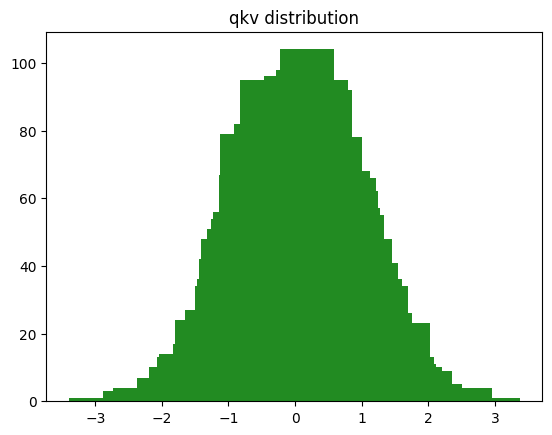

In [ ]:
import matplotlib.pyplot as plt

# torch.histc cria histograma (conta com qual frequẽncia dos elementos caem em intervalos (bins) de tamanho igual)
y_val = torch.histc(qkv, bins=200, min=3, max=3)
# Cria array (start, stop, step)
x_val = np.arange(-1,1,0.01) * 3
plt.bar(x_val, y_val, align='center', color=['forestgreen'])
plt.title('qkv distribution')

In [8]:
num_heads = 8
head_dim = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_lenght, num_heads, 3 * head_dim)

qkv.shape

torch.Size([1, 4, 8, 192])

Cortamos a matriz em 8.

In [11]:
# Trocamos a 1° e 2° dimensões para facilitar operações paralelas nas duas últimas dimensões
qkv = qkv.permute(0, 2, 1, 3) # [batch_size, num_heads, sequence_lenght, 3*head_dim]
qkv.shape

torch.Size([1, 8, 4, 192])

In [13]:
# Quebramos a matriz em 3 matrizes
q, k, v = qkv.chunk(3, dim=-1) # Pega a última dimensão
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

## Self Attention for Multiple Heads

$$\text{Self Attention} = \text{Softmax}(\frac{Q \cdot K^T}{\sqrt{d_k}}+M)$$

$$\text{New V} = \text{Self Attention} \cdot V$$

In [ ]:
d_k = q.size()[-1]
# Por ser um tensor (e não matriz 2D), temos que especificar quais dimensões vamos transpor
scaled = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])

Isso já aplica a softmax a todos os 8 cabeçotes! (graças aos tensores)

Obs: Em k.transpose, a ordem das dimensões não importa.

In [17]:
k.T.shape

torch.Size([64, 4, 8, 1])

In [19]:
# Gera máscara cheia
mask = torch.full(scaled.size(), float('-inf'))
mask = torch.triu(mask, diagonal=1)
mask[0][1] # Mask for input to a single head

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [21]:
scaled += mask
scaled[0][0]

tensor([[ 0.0070,    -inf,    -inf,    -inf],
        [ 0.0278,  0.0168,    -inf,    -inf],
        [ 0.1244,  0.0200,  0.1475,    -inf],
        [ 0.0473, -0.0488, -0.0177,  0.0987]], grad_fn=<SelectBackward0>)

In [30]:
attention = F.softmax(scaled, dim=-1) # F possui softmax
attention.shape

torch.Size([1, 8, 4, 4])

In [27]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5027, 0.4973, 0.0000, 0.0000],
        [0.3420, 0.3081, 0.3500, 0.0000],
        [0.2565, 0.2330, 0.2404, 0.2701]], grad_fn=<SelectBackward0>)

In [28]:
values = torch.matmul(attention, v)
values.shape

torch.Size([1, 8, 4, 64])

In [5]:
# Final Function
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention


In [6]:
values, attention = scaled_dot_product(q, k, v, mask=None)

NameError: name 'q' is not defined

In [34]:
attention.shape

torch.Size([1, 8, 4, 4])

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, input_dim, d_model, num_heads):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv_layer = nn.Linear(input_dim, 3 * d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, sequence_lenght, input_dim = x.size()
        print(f"x.size(): {x.size()}")
        qkv = self.qkv_layer(x)
        print(f"qkv.size:(): {qkv.size()}")
        qkv = qkv.reshape(batch_size, sequence_lenght, self.num_heads, 3 * self.head_dim)
        print(f"qkv.size(): {qkv.size()}")
        qkv = qkv.permute(0,2,1,3)
        print(f"qkv.size(): {qkv.size()}")
        q, k, v = qkv.chunk(3, dim=-1)
        print(f"q size: {q.size()}, k size: {k.size()}, v size: {v.size()}")
        values, attention = scaled_dot_product(q, k, v, mask)
        print(f"values.size: {values.size()}, attention.size: {attention.size()}")
        values = values.reshape(batch_size, sequence_lenght, self.num_heads * self.head_dim)
        print(f"values.size(): {values.size()}")
        out = self.linear_layer(values)
        return out
        

## Input

In [8]:
input_dim = 1024
d_model = 512
num_heads = 8

batch_size = 30
sequence_lenght = 5
x = torch.randn((batch_size, sequence_lenght, input_dim))

model = MultiHeadAttention(input_dim, d_model, num_heads)
out = model.forward(x)

x.size(): torch.Size([30, 5, 1024])
qkv.size:(): torch.Size([30, 5, 1536])
qkv.size(): torch.Size([30, 5, 8, 192])
qkv.size(): torch.Size([30, 8, 5, 192])
q size: torch.Size([30, 8, 5, 64]), k size: torch.Size([30, 8, 5, 64]), v size: torch.Size([30, 8, 5, 64])
values.size: torch.Size([30, 8, 5, 64]), attention.size: torch.Size([30, 8, 5, 5])
values.size(): torch.Size([30, 5, 512])
